In [1]:
import numpy as np
import csv
import pandas as pd
import mne

In [ ]:
puzzle_info = pd.read_csv('Participant_1_puzzle_results.csv')
puzzle_info["timestamp_unix"] = puzzle_info["timestamp_unix"]*1000

eeg_column_names = ["F3", "F4", "P4", "T7", "O1", "O2","P8","P7","x","y","z","keypoint","time"] 
column_to_pick = [0,1,2,3,4,5,6,7,12]
eeg_data = pd.read_csv('20251121150014_Patient01_First step.easy', sep='\t',usecols = column_to_pick, header=None, names=eeg_column_names)

print(eeg_data)

              F3        F4        P4        P3       O1       O2       P8  \
0       11562397  11085401  13450293  13931594  5642929  4343548  5664117   
1       11468250  10989589  13354082  13835017  5550560  4249792  5572449   
2       11408511  10927980  13294905  13776354  5493505  4195943  5512934   
3       11397612  10915455  13284639  13767012  5484119  4187773  5499917   
4       11443069  10959374  13327733  13809983  5526012  4229002  5540076   
...          ...       ...       ...       ...      ...      ...      ...   
280483  13183142  12895153  15585694  15784926  8329017  7814602  8532887   
280484  13175441  12890307  15579895  15780091  8321772  7814022  8530543   
280485  13166456  12878613  15571658  15768343  8313598  7809229  8522638   
280486  13152703  12868697  15561060  15756350  8301032  7798792  8512025   
280487  13140656  12861282  15551482  15747026  8286325  7786271  8502805   

             P7           time  
0        313115  1763737214188  
1        

In [ ]:

puzzle_eeg = {}
print(puzzle_info["timestamp_unix"][0])
puzzle_num = 0
puzzle 


1763737278695.198


In [ ]:
timestamps = puzzle_info["timestamp_unix"].values

puzzle_eeg_data = []

# Loop through each interval
for i in range(len(timestamps)):
    if i == 0:
        # Start from beginning of eeg_data
        start_time = eeg_data["time"].min()
    else:
        start_time = timestamps[i - 1]
        
    end_time = timestamps[i]

    # Slice eeg_data for this segment
    segment = eeg_data[(eeg_data["time"] >= start_time) &
                       (eeg_data["time"] < end_time)]

    puzzle_eeg_data.append(segment)

print(puzzle_eeg_data[20])

              F3        F4        P4        P3       O1       O2       P8  \
235369  13281996  13002669  15685019  15927049  8227115  7636937  8402159   
235370  13271134  12990669  15668520  15910701  8214858  7618616  8383791   
235371  13251114  12972038  15645346  15887106  8188993  7590952  8359165   
235372  13233622  12944421  15627810  15870318  8168149  7569622  8339960   
235373  13232608  12949276  15631847  15872886  8171226  7573832  8344469   
...          ...       ...       ...       ...      ...      ...      ...   
270207  13177200  12906503  15599562  15827122  8306177  7801152  8503784   
270208  13171581  12896429  15594932  15823471  8308749  7790378  8501420   
270209  13166210  12889201  15586147  15812838  8299802  7779672  8496415   
270210  13151467  12876231  15567484  15794991  8279604  7754491  8477768   
270211  13125723  12856245  15547919  15774653  8268675  7740776  8455118   

             P7           time  
235369  3546096  1763737684937  
235370  3

In [4]:
puzzle_eeg_data_mne = []
channel_names = ["F3", "F4", "P4", "P3", "O1", "O2","P8","P7"]
for puzzle in puzzle_eeg_data:
    data = puzzle.drop(columns=["time"]).to_numpy().T
    info = mne.create_info(
        ch_names=channel_names,
        sfreq=500,
        ch_types="eeg"
    )
    raw = mne.io.RawArray(data, info)
    puzzle_eeg_data_mne.append(raw)

print(puzzle_eeg_data_mne[0])


Creating RawArray with float64 data, n_channels=8, n_times=32253
    Range : 0 ... 32252 =      0.000 ...    64.504 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=12737
    Range : 0 ... 12736 =      0.000 ...    25.472 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=15367
    Range : 0 ... 15366 =      0.000 ...    30.732 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=7628
    Range : 0 ... 7627 =      0.000 ...    15.254 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=6770
    Range : 0 ... 6769 =      0.000 ...    13.538 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=5815
    Range : 0 ... 5814 =      0.000 ...    11.628 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=6038
    Range : 0 ... 6037 =      0.000 ...    12.074 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=7420
    Range : 0 ... 7419 =      0.000 ...    14.83

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 4.096 (s)
converting legacy list-of-tuples input to a dict for the `bands` parameter


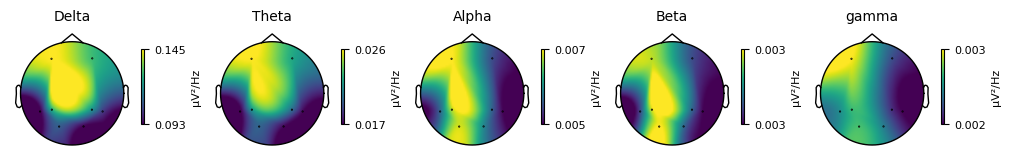

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 4.096 (s)
converting legacy list-of-tuples input to a dict for the `bands` parameter


c:\Users\vs814\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


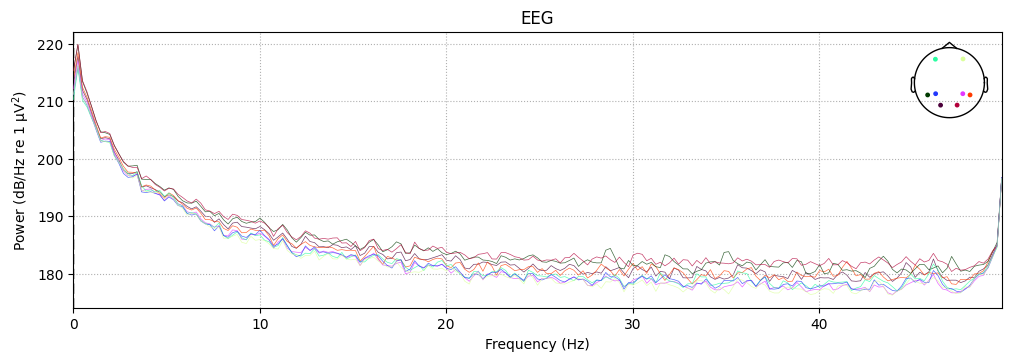

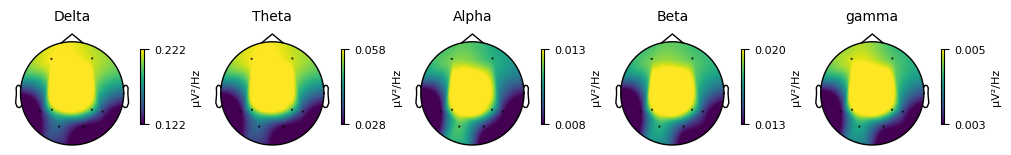

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\vs814\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


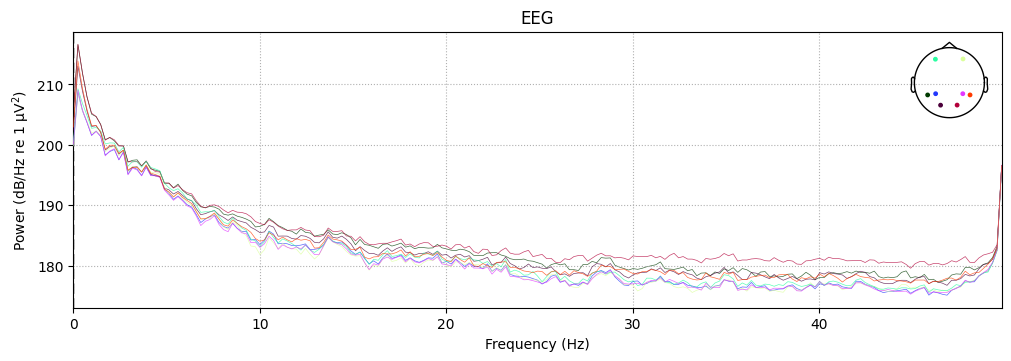

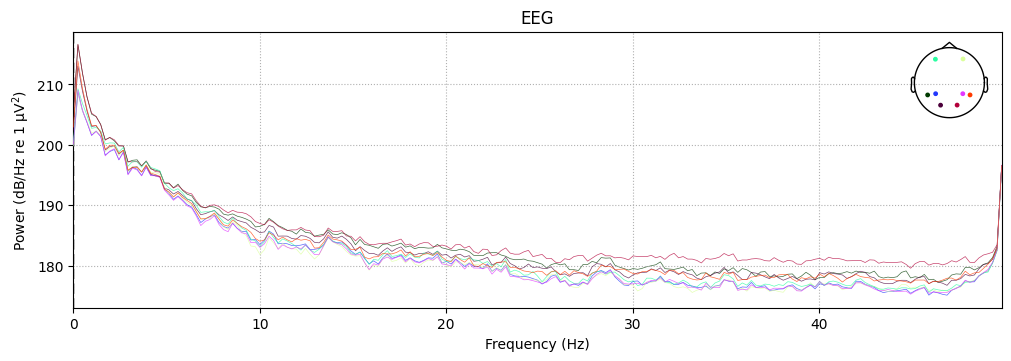

In [7]:
solved_puzzles_eeg_data_mne = [eeg_data[1] for eeg_data in enumerate(puzzle_eeg_data_mne) if puzzle_info["accuracy"][eeg_data[0]] == 1]
all_solved_puzzles_eeg_data_mne = mne.concatenate_raws(solved_puzzles_eeg_data_mne)

failed_puzzles_eeg_data_mne = [eeg_data[1] for eeg_data in enumerate(puzzle_eeg_data_mne) if puzzle_info["accuracy"][eeg_data[0]] == 0]
all_failed_puzzles_eeg_data_mne = mne.concatenate_raws(failed_puzzles_eeg_data_mne)

montage = mne.channels.make_standard_montage("standard_1020")
puzzle_num = 20
all_solved_puzzles_eeg_data_mne.set_montage(montage)
all_failed_puzzles_eeg_data_mne.set_montage(montage)
all_solved_puzzles_eeg_data_mne.plot_psd_topomap(
    bands=[(1, 4, 'Delta'),
           (4, 8, 'Theta'),
           (8, 12, 'Alpha'),
           (12, 16, 'Beta'),
           (16,20,"gamma")],
    normalize=True,
    cmap='viridis'
)
all_solved_puzzles_eeg_data_mne.plot_psd(fmax=50)
all_failed_puzzles_eeg_data_mne.plot_psd_topomap(
    bands=[(1, 4, 'Delta'),
           (4, 8, 'Theta'),
           (8, 12, 'Alpha'),
           (12, 30, 'Beta'),
           (16,20,"gamma")],
    normalize=True,
    cmap='viridis'
)
all_failed_puzzles_eeg_data_mne.plot_psd(fmax=50)

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 4.096 (s)
converting legacy list-of-tuples input to a dict for the `bands` parameter


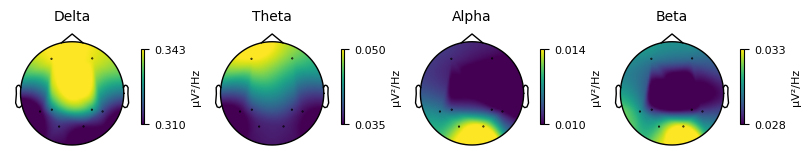

In [43]:
montage = mne.channels.make_standard_montage("standard_1020")
puzzle_num = 20
puzzle_eeg_data_mne[puzzle_num].set_montage(montage)
puzzle_eeg_data_mne[puzzle_num].plot_psd_topomap(
    bands=[(1, 4, 'Delta'),
           (4, 8, 'Theta'),
           (8, 12, 'Alpha'),
           (12, 30, 'Beta')],
    normalize=True,
    cmap='viridis'
);

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\vs814\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


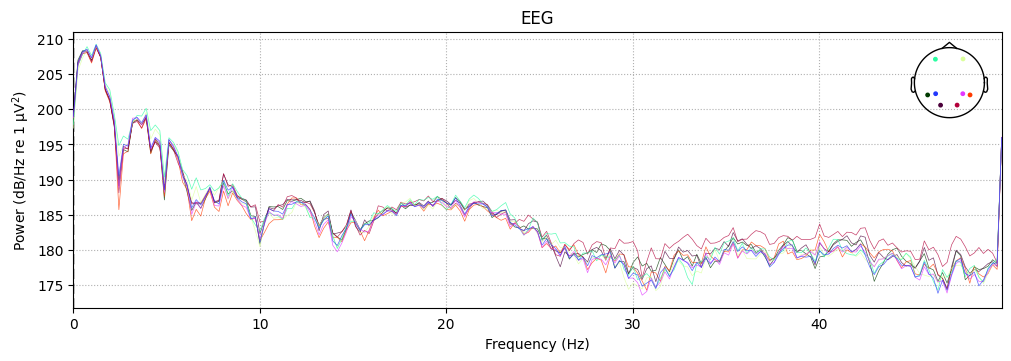

In [36]:
puzzle_eeg_data_mne[20].plot_psd(fmax=50)

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 4.096 (s)
converting legacy list-of-tuples input to a dict for the `bands` parameter


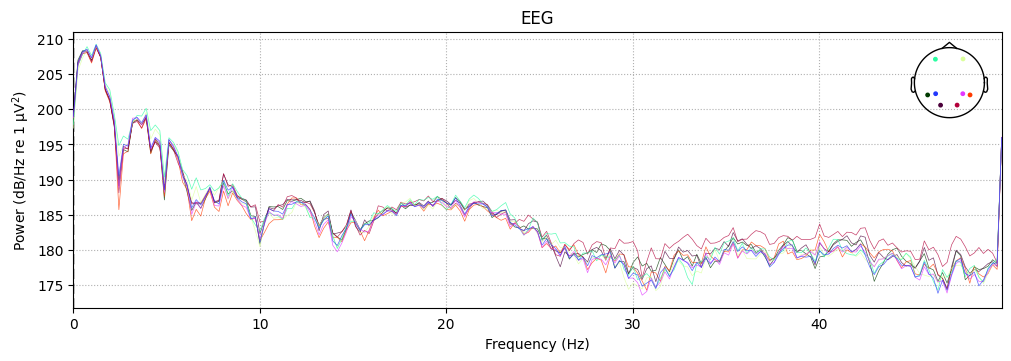

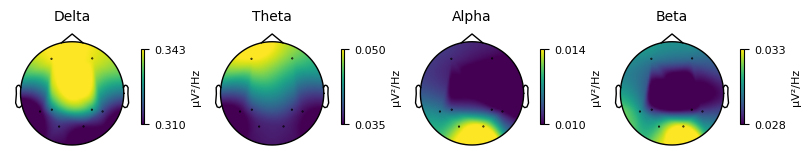

In [37]:
puzzle_eeg_data_mne[20].plot_psd_topomap(
    bands=[(1, 4, 'Delta'),
           (4, 8, 'Theta'),
           (8, 12, 'Alpha'),
           (12, 30, 'Beta')],
    normalize=True,
    cmap='viridis'
);